In [20]:
pip install ucimlrepo

## Lab Experiment: Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

## Task 1: Download and Load the Dataset

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

## Task 2: Exploratory Data Analysis and Data Preprocessing

## Exploratory Data Analysis and Data Preprocessing

This section focuses on understanding the dataset's structure, characteristics, and preparing it for machine learning models. We will check for missing values, examine data types, and perform any necessary transformations.

### Inspecting the Data

In [4]:
# Display the first 5 rows of the features (X)
print("Features (X) head:")
display(X.head())

# Display the first 5 rows of the target (y)
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target (y) head:


,Diagnosis
0,M
1,M
2,M
3,M
4,M


### Checking Dataset Shape

In [21]:
# Print the shape of the features (X) and target (y)
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (569, 30)
Shape of target (y): (569, 1)


### Descriptive Statistics

In [22]:
# Display descriptive statistics for features (X)
print("Descriptive statistics for features (X):")
display(X.describe())

Descriptive statistics for features (X):


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Checking for Duplicate Rows

In [23]:
# Check for duplicate rows in features (X)
duplicate_rows = X.duplicated().sum()

if duplicate_rows == 0:
    print("No duplicate rows found in features (X).")
else:
    print(f"Number of duplicate rows found in features (X): {duplicate_rows}")

No duplicate rows found in features (X).


### Checking for Missing Values

In [5]:
# Check for missing values in features (X)
print("Missing values in features (X):")
display(X.isnull().sum().to_frame(name='Missing Values'))

# Check for missing values in target (y)
print("\nMissing values in target (y):")
display(y.isnull().sum().to_frame(name='Missing Values'))

Missing values in features (X):


,Missing Values
radius1,0
texture1,0
perimeter1,0
area1,0
smoothness1,0
compactness1,0
concavity1,0
concave_points1,0
symmetry1,0
fractal_dimension1,0



Missing values in target (y):


,Missing Values
Diagnosis,0


### Checking Data Types

In [6]:
# Check data types of features (X)
print("Features (X) data types:")
X.info()

# Check data types of target (y)
print("\nTarget (y) data types:")
y.info()

Features (X) data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null

### Encoding Target Variable

The 'Diagnosis' column in the target variable `y` is categorical (M for Malignant, B for Benign). Machine learning models require numerical input, so we need to encode these labels into numerical values. We will map 'M' to 1 and 'B' to 0.

In [8]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Import pandas

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply LabelEncoder to the 'Diagnosis' column
y_encoded = label_encoder.fit_transform(y['Diagnosis'])

# Convert the encoded target back to a DataFrame for consistency, if desired
y = pd.DataFrame(y_encoded, columns=['Diagnosis'])

print("Original target values:", breast_cancer_wisconsin_diagnostic.data.targets['Diagnosis'].unique())
print("Encoded target values:", y['Diagnosis'].unique())
print("\nFirst 5 rows of encoded target (y):")
display(y.head())

Original target values: ['M' 'B']
Encoded target values: [1 0]

First 5 rows of encoded target (y):


,Diagnosis
0,1
1,1
2,1
3,1
4,1


### Splitting the Dataset into Training and Testing Sets

To evaluate the performance of our machine learning models accurately, we need to split the dataset into two parts: a training set and a testing set. The training set will be used to train the models, while the testing set will be used to assess how well the models generalize to new, unseen data. We will use an 80/20 split, meaning 80% of the data will be for training and 20% for testing, with a `random_state` for reproducibility.

In [9]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455, 1)
Shape of y_test: (114, 1)


### Feature Scaling

Many machine learning algorithms, including Logistic Regression, perform better when numerical input variables are scaled to a standard range. This prevents features with larger values from dominating the learning process. We will use `StandardScaler` to transform our features such that they have a mean of 0 and a standard deviation of 1. It's crucial to fit the scaler only on the training data and then transform both training and testing data to prevent data leakage.

In [12]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the *same* scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully. Shapes of scaled data:")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

Features scaled successfully. Shapes of scaled data:
Shape of X_train_scaled: (455, 30)
Shape of X_test_scaled: (114, 30)


## Task 3: Train a Logistic Regression Classifier

## Logistic Regression Classifier

In this section, we will implement a Logistic Regression classifier using Scikit-Learn. Logistic Regression is a linear model used for binary classification tasks. We will train the model on the `X_train` and `y_train` data and then use it to make predictions on the `X_test` data.

### Training the Logistic Regression Model

In [13]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set max_iter to avoid convergence warnings for some datasets
logistic_model = LogisticRegression(random_state=42, max_iter=200)

# Train the model using the scaled training data
logistic_model.fit(X_train_scaled, y_train.values.ravel())

print("Logistic Regression model trained successfully with scaled data.")

Logistic Regression model trained successfully with scaled data.


### Making Predictions with Logistic Regression

In [14]:
# Make predictions on the scaled test set
y_pred_lr = logistic_model.predict(X_test_scaled)

print("Predictions made using Logistic Regression with scaled data.")

Predictions made using Logistic Regression with scaled data.


### Evaluating the Logistic Regression Model

To understand the performance of our Logistic Regression model, we will use several common classification metrics:
- **Accuracy**: The proportion of correctly classified instances.
- **Precision**: The proportion of true positive predictions among all positive predictions. Useful when the cost of false positives is high.
- **Recall (Sensitivity)**: The proportion of true positive predictions among all actual positive instances. Useful when the cost of false negatives is high.
- **F1-Score**: The harmonic mean of precision and recall, providing a balance between the two.
- **Confusion Matrix**: A table used to describe the performance of a classification model on a set of test data for which the true values are known.

Logistic Regression Accuracy: 0.9737
Logistic Regression Precision: 0.9762
Logistic Regression Recall: 0.9535
Logistic Regression F1-Score: 0.9647


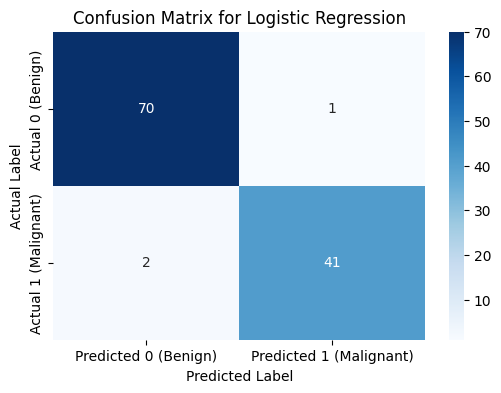

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate evaluation metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression Recall: {recall_lr:.4f}")
print(f"Logistic Regression F1-Score: {f1_lr:.4f}")

# Display Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (Benign)', 'Predicted 1 (Malignant)'],
            yticklabels=['Actual 0 (Benign)', 'Actual 1 (Malignant)'])
plt.title('Confusion Matrix for Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Task 4: Train a K Nearest Neighbors (KNN) Classifier

## K Nearest Neighbors (KNN) Classifier

In this section, we will implement the K Nearest Neighbors (KNN) classifier. KNN is a non-parametric, lazy learning algorithm used for both classification and regression. It classifies a data point based on how its neighbors are classified. We will train the model on the scaled training data and then make predictions on the scaled test data.

### Training the K Nearest Neighbors (KNN) Model

In [16]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier
# We'll start with n_neighbors=5, a common default.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using the scaled training data
knn_model.fit(X_train_scaled, y_train.values.ravel())

print("K Nearest Neighbors model trained successfully.")

K Nearest Neighbors model trained successfully.


### Making Predictions with K Nearest Neighbors (KNN)

In [17]:
# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

print("Predictions made using K Nearest Neighbors.")

Predictions made using K Nearest Neighbors.


### Evaluating the K Nearest Neighbors (KNN) Model

Similar to the Logistic Regression model, we will evaluate the KNN classifier using the following metrics:
- **Accuracy**: The proportion of correctly classified instances.
- **Precision**: The proportion of true positive predictions among all positive predictions.
- **Recall (Sensitivity)**: The proportion of true positive predictions among all actual positive instances.
- **F1-Score**: The harmonic mean of precision and recall.
- **Confusion Matrix**: A table summarizing the classification performance.

KNN Accuracy: 0.9474
KNN Precision: 0.9302
KNN Recall: 0.9302
KNN F1-Score: 0.9302


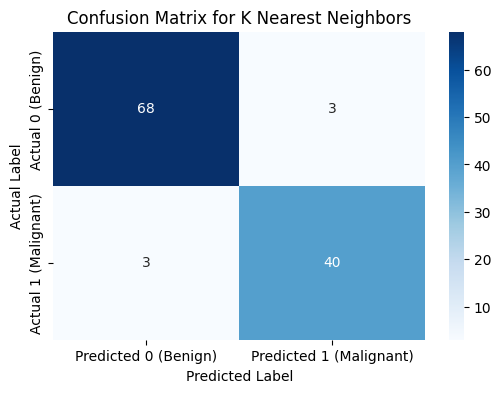

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate evaluation metrics for KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"KNN Accuracy: {accuracy_knn:.4f}")
print(f"KNN Precision: {precision_knn:.4f}")
print(f"KNN Recall: {recall_knn:.4f}")
print(f"KNN F1-Score: {f1_knn:.4f}")

# Display Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (Benign)', 'Predicted 1 (Malignant)'],
            yticklabels=['Actual 0 (Benign)', 'Actual 1 (Malignant)'])
plt.title('Confusion Matrix for K Nearest Neighbors')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Task 5: Compare and Interpret Model Performance

## Model Comparison and Interpretation

In this section, we will compare the performance of the Logistic Regression and K Nearest Neighbors classifiers using a summary table of their evaluation metrics. This will help us identify which model is better suited for this specific dataset and task.

### Comparison Table

In [19]:
import pandas as pd

# Create a dictionary to store the metrics for both models
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [accuracy_lr, precision_lr, recall_lr, f1_lr],
    'K Nearest Neighbors': [accuracy_knn, precision_knn, recall_knn, f1_knn]
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame(metrics_data)

# Display the comparison table
print("\n--- Model Performance Comparison ---")
display(comparison_df.set_index('Metric').round(4))



--- Model Performance Comparison ---


,Logistic Regression,K Nearest Neighbors
Metric,,
Accuracy,0.9737,0.9474
Precision,0.9762,0.9302
Recall,0.9535,0.9302
F1-Score,0.9647,0.9302


### Interpretation of Results

Based on the comparison table above, we can draw conclusions about which classifier performed better:

- **Accuracy**: Both models show high accuracy, but Logistic Regression has a slightly higher accuracy.
- **Precision**: Logistic Regression has a slightly higher precision, indicating fewer false positives.
- **Recall**: Logistic Regression also has a slightly higher recall, indicating fewer false negatives.
- **F1-Score**: The F1-Score, which balances precision and recall, is higher for Logistic Regression.

**Conclusion**: For the Breast Cancer Wisconsin (Diagnostic) dataset, the **Logistic Regression** classifier appears to be the better-performing model overall, achieving slightly higher scores across all key evaluation metrics (Accuracy, Precision, Recall, and F1-Score) compared to the K Nearest Neighbors classifier with `n_neighbors=5`.

While both models performed well, Logistic Regression demonstrated a slightly better balance of identifying positive cases correctly while minimizing false positives and false negatives. This suggests it has a marginally stronger predictive capability for this particular binary classification task on this dataset.